In [37]:
import pandas as pd 
import numpy as np
from sklearn.datasets import make_regression
import plotly.graph_objects as go 

In [2]:
x,y=make_regression(n_samples=100,n_features=2,n_informative=2, n_targets=1 ,noise=50)

In [3]:
df=pd.DataFrame({'feature 1':x[:,0],'feature 2': x[:,1] ,'target' :y})

In [4]:
df.head()

,feature 1,feature 2,target
0,-0.943384,-0.070691,-45.495043
1,-0.000804,-0.827888,-21.334463
2,1.331097,-0.239179,-21.599301
3,0.324115,-1.439834,-77.830823
4,0.056861,0.087061,6.730394


In [5]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable


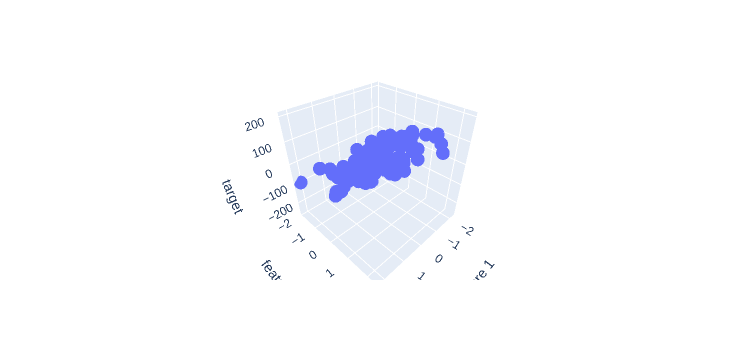

In [9]:
import plotly.express as px 
px.scatter_3d(df,x='feature 1', y='feature 2', z='target')

In [7]:
!which python 
!pip show plotly 

Name: plotly
Version: 6.6.0
Summary: An open-source interactive data visualization library for Python
Home-page: 
Author: 
Author-email: Chris P <chris@plot.ly>
License: MIT License
        
        Copyright (c) 2016-2024 Plotly Technologies Inc.
        
        Permission is hereby granted, free of charge, to any person obtaining a copy
        of this software and associated documentation files (the "Software"), to deal
        in the Software without restriction, including without limitation the rights
        to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
        copies of the Software, and to permit persons to whom the Software is
        furnished to do so, subject to the following conditions:
        
        The above copyright notice and this permission notice shall be included in
        all copies or substantial portions of the Software.
        
        THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
        IMPLIED, I

In [8]:
import sys
!{sys.executable} -m pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.9 MB/s  0:00:02a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]━━━━ 1/2 [plotly]


In [28]:
from sklearn.linear_model  import LinearRegression 
lr=LinearRegression()
from sklearn.model_selection import train_test_split
x_=df.iloc[:,0:2]
y=df.iloc[:,2:3]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

array([[ -69.32123699],
       [ -62.30314549],
       [  56.86895237],
       [-100.67452224],
       [   8.5743694 ],
       [-139.09853975],
       [  -5.50416882],
       [  35.13434124],
       [  61.80955675],
       [  81.6291742 ],
       [  46.21615738],
       [ 102.16639284],
       [  58.28015065],
       [ -53.63350071],
       [ -25.700687  ],
       [-163.48418347],
       [-124.81633331],
       [ -11.98781804],
       [  30.41666003],
       [  89.35466736]])

In [29]:
y_pred=pd.DataFrame(y_pred,columns=['target'])
y_pred


,target
0,-69.321237
1,-62.303145
2,56.868952
3,-100.674522
4,8.574369
5,-139.098540
6,-5.504169
7,35.134341
8,61.809557
9,81.629174


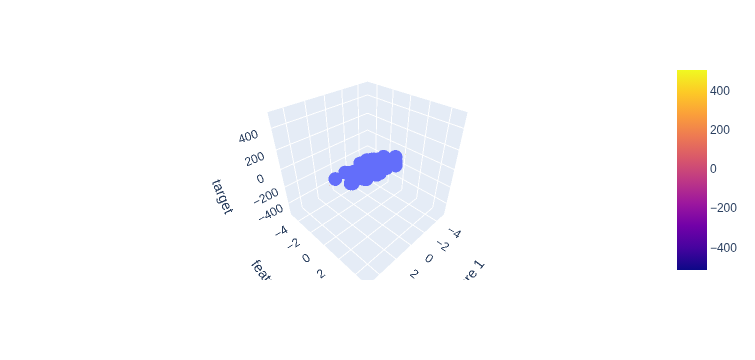

In [38]:
x=np.linspace(-5,5,10)
y=np.linspace(-5,5,10)
xGrid, yGrid =np.meshgrid(y,x)
final=np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final=lr.predict(final).reshape(10,10)
z=z_final
fig=px.scatter_3d(df,x='feature 1',y='feature 2' , z='target')
fig.add_trace(go.Surface(x=x,y=y,z=z))
fig.show()